# Cell Tuning Analysis

This notebook implements comprehensive statistical tests to determine if cells are tuned to:
1. **Task modulation** (Baseline vs GO)
2. **Direction tuning** (Left vs Right)
3. **Signal processing** (STOP vs CONT, **correctly aligned to stop_cue**)
4. **Signal vs GO** (Does STOP/CONT signal change activity differently than GO?)

**IMPORTANT**: STOP/CONT trials are aligned to `stop_cue` (not `go_cue`) to properly measure signal responses.

**Methods:**
- ANOVA for main effects
- Effect size measures (Cohen's d, eta-squared)
- Direction and signal selectivity indices
- Multiple comparison correction (Bonferroni)

In [1]:
# Imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import holoviews as hv
import hvplot.pandas
hv.extension('bokeh')

from scipy import stats
from scipy.stats import f_oneway, ttest_ind
from pprint import pprint
from itertools import combinations

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

# Import classes
import importlib
import session_class
import cell_analysis
importlib.reload(session_class)
importlib.reload(cell_analysis)
from session_class import Session
from cell_analysis import Cell, PopulationAnalyzer

print("✓ Imports loaded successfully!")

✓ Imports loaded successfully!


In [2]:
# Analysis windows (ms)
WINDOWS = {
    'baseline': [-500, 0],
    'go_task': [0, 300],
    'direction': [0, 250],
    'signal': [0, 250],
}

print('✓ Analysis windows set:', WINDOWS)


✓ Analysis windows set: {'baseline': [-500, 0], 'go_task': [0, 300], 'direction': [0, 250], 'signal': [0, 250]}


## 1. Load Data

In [3]:
# Load MSN cell database
monkey = 'fiona'
base_path = Path.cwd().parent / 'data' / 'unified_cell_trial_data' 
pickle_file = base_path / f'msn_{monkey}_cell_trial_data.pkl'
cell_df = pd.read_pickle(pickle_file)

# Select session with most cells
session_cell_counts = cell_df.groupby('trial_session')['cell_ID'].nunique().sort_values(ascending=False)
best_session_id = session_cell_counts.index[0]
# best_session_id = "fi210810a"

print(f"Using session: {best_session_id}")
print(f"Number of cells: {session_cell_counts.iloc[0]}")

# Create Session object
session_data = cell_df[cell_df['trial_session'] == best_session_id]
session = Session(session_data, verbose=True)

Using session: fi211102a
Number of cells: 189
Session fi211102a initialized:
  - Number of cells: 189
  - Total trials: 1813
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]


## 2. Helper Functions - CORRECTED

In [4]:
def get_firing_rates(cell, align_event, window, trial_type=None, direction=None, success_only=True):
    """
    Extract firing rates for specific conditions.
    
    Parameters:
    -----------
    cell : Cell
        Cell object
    align_event : str
        'go_cue' or 'stop_cue'
    window : list
        Time window [start, end] in ms
    trial_type : str, optional
        'GO', 'STOP', or 'CONT'
    direction : int, optional
        0 (right) or 180 (left)
    success_only : bool
        Include only successful trials
    
    Returns:
    --------
    np.array : Firing rates in spikes/sec
    """
    # Filter trials
    df = cell.filter_trials(trial_type=trial_type, direction=direction, success_only=success_only)
    
    rates = []
    for _, row in df.iterrows():
        # Get alignment time
        if align_event == 'go_cue':
            t0 = row['go_cue']
        elif align_event == 'stop_cue':
            t0 = row['stop_cue']
        else:
            raise ValueError(f"Unknown align_event: {align_event}")
        
        # Skip if alignment event is missing
        if pd.isna(t0):
            continue
            
        spikes = np.array(row['neural_data'], dtype=float)
        aligned_spikes = spikes - t0
        
        # Count spikes in window
        count = np.sum((aligned_spikes >= window[0]) & (aligned_spikes <= window[1]))
        duration = (window[1] - window[0]) / 1000.0  # Convert to seconds
        rates.append(count / duration)
        
    return np.array(rates)


def cohens_d(group1, group2):
    """Calculate Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return np.nan
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    if pooled_std == 0:
        return 0.0
    
    return (np.mean(group1) - np.mean(group2)) / pooled_std


def eta_squared(groups):
    """Calculate eta-squared effect size for ANOVA."""
    all_data = np.concatenate(groups)
    grand_mean = np.mean(all_data)
    
    ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
    ss_total = np.sum((all_data - grand_mean)**2)
    
    if ss_total == 0:
        return 0.0
    
    return ss_between / ss_total


def direction_selectivity_index(left_rate, right_rate):
    """Calculate direction selectivity index."""
    if left_rate + right_rate == 0:
        return 0.0
    return (left_rate - right_rate) / (left_rate + right_rate)


def modulation_index(baseline_rate, task_rate):
    """Calculate modulation index."""
    if baseline_rate + task_rate == 0:
        return 0.0
    return (task_rate - baseline_rate) / (task_rate + baseline_rate)


def signal_selectivity_index(stop_rate, cont_rate):
    """Calculate signal selectivity index (STOP vs CONT)."""
    if stop_rate + cont_rate == 0:
        return 0.0
    return (stop_rate - cont_rate) / (stop_rate + cont_rate)

print("✓ Helper functions defined")

✓ Helper functions defined


## 3. Main Tuning Analysis Function - CORRECTED

In [5]:
def analyze_cell_tuning(cell, alpha=0.05, verbose=False):
    """
    Comprehensive tuning analysis with CORRECTED alignment for STOP/CONT trials.
    
    Key fix: STOP and CONT trials are aligned to stop_cue, not go_cue.
    
    Parameters:
    -----------
    cell : Cell
        Cell object to analyze
    alpha : float
        Significance level (default: 0.05)
    verbose : bool
        Print detailed results
    
    Returns:
    --------
    dict : Comprehensive tuning results
    """
    results = {
        'cell_id': cell.cell_id,
        'cell_type': cell.cell_type,
    }
    
    n_tests = 6  # Increased: task_mod, direction, stop_mod, cont_mod, signal_discrimination, go_vs_signal
    bonferroni_alpha = alpha / n_tests
    
    # ========================================
    # 1. BASELINE (from GO trials)
    # ========================================
    baseline_rates = get_firing_rates(cell, 'go_cue', WINDOWS['baseline'], trial_type='GO')
    
    # ========================================
    # 2. TASK MODULATION (Baseline vs GO)
    # ========================================
    go_rates = get_firing_rates(cell, 'go_cue', WINDOWS['go_task'], trial_type='GO')
    
    if len(baseline_rates) > 0 and len(go_rates) > 0:
        f_stat, p_val = f_oneway(baseline_rates, go_rates)
        effect_size = cohens_d(go_rates, baseline_rates)
        eta2 = eta_squared([baseline_rates, go_rates])
        
        results['task_modulation'] = {
            'F': f_stat,
            'p': p_val,
            'p_bonferroni': p_val * n_tests,
            'significant': p_val < bonferroni_alpha,
            'cohens_d': effect_size,
            'eta_squared': eta2,
            'modulation_index': modulation_index(np.mean(baseline_rates), np.mean(go_rates)),
            'baseline_mean': np.mean(baseline_rates),
            'go_mean': np.mean(go_rates)
        }
    else:
        results['task_modulation'] = {'significant': False}
    
    # ========================================
    # 3. DIRECTION TUNING (on GO trials)
    # ========================================
    go_left = get_firing_rates(cell, 'go_cue', WINDOWS['direction'], trial_type='GO', direction=180)
    go_right = get_firing_rates(cell, 'go_cue', WINDOWS['direction'], trial_type='GO', direction=0)
    
    if len(go_left) > 0 and len(go_right) > 0:
        f_stat, p_val = f_oneway(go_left, go_right)
        effect_size = cohens_d(go_left, go_right)
        dsi = direction_selectivity_index(np.mean(go_left), np.mean(go_right))
        
        results['direction_tuning'] = {
            'F': f_stat,
            'p': p_val,
            'p_bonferroni': p_val * n_tests,
            'significant': p_val < bonferroni_alpha,
            'cohens_d': effect_size,
            'direction_selectivity_index': dsi,
            'preferred_direction': 'left' if dsi > 0 else 'right',
            'left_mean': np.mean(go_left),
            'right_mean': np.mean(go_right)
        }
    else:
        results['direction_tuning'] = {'significant': False}
    
    # ========================================
    # 4. STOP MODULATION (Baseline vs STOP response)
    # CORRECTED: Align to stop_cue!
    # ========================================
    stop_rates = get_firing_rates(cell, 'stop_cue', WINDOWS['signal'], trial_type='STOP')
    
    if len(baseline_rates) > 0 and len(stop_rates) > 0:
        f_stat, p_val = f_oneway(baseline_rates, stop_rates)
        effect_size = cohens_d(stop_rates, baseline_rates)
        mi = modulation_index(np.mean(baseline_rates), np.mean(stop_rates))
        
        results['stop_modulation'] = {
            'F': f_stat,
            'p': p_val,
            'p_bonferroni': p_val * n_tests,
            'significant': p_val < bonferroni_alpha,
            'cohens_d': effect_size,
            'modulation_index': mi,
            'stop_mean': np.mean(stop_rates)
        }
    else:
        results['stop_modulation'] = {'significant': False}
    
    # ========================================
    # 5. CONT MODULATION (Baseline vs CONT response)
    # CORRECTED: Align to stop_cue!
    # ========================================
    cont_rates = get_firing_rates(cell, 'stop_cue', WINDOWS['signal'], trial_type='CONT')
    
    if len(baseline_rates) > 0 and len(cont_rates) > 0:
        f_stat, p_val = f_oneway(baseline_rates, cont_rates)
        effect_size = cohens_d(cont_rates, baseline_rates)
        mi = modulation_index(np.mean(baseline_rates), np.mean(cont_rates))
        
        results['cont_modulation'] = {
            'F': f_stat,
            'p': p_val,
            'p_bonferroni': p_val * n_tests,
            'significant': p_val < bonferroni_alpha,
            'cohens_d': effect_size,
            'modulation_index': mi,
            'cont_mean': np.mean(cont_rates)
        }
    else:
        results['cont_modulation'] = {'significant': False}
    
    # ========================================
    # 6. SIGNAL DISCRIMINATION (STOP vs CONT)
    # Both aligned to stop_cue
    # ========================================
    if len(stop_rates) > 0 and len(cont_rates) > 0:
        f_stat, p_val = f_oneway(stop_rates, cont_rates)
        effect_size = cohens_d(stop_rates, cont_rates)
        ssi = signal_selectivity_index(np.mean(stop_rates), np.mean(cont_rates))
        
        results['signal_discrimination'] = {
            'F': f_stat,
            'p': p_val,
            'p_bonferroni': p_val * n_tests,
            'significant': p_val < bonferroni_alpha,
            'cohens_d': effect_size,
            'signal_selectivity_index': ssi,
            'preferred_signal': 'STOP' if ssi > 0 else 'CONT'
        }
    else:
        results['signal_discrimination'] = {'significant': False}
    
    # ========================================
    # 7. GO vs SIGNALS (does signal differ from GO?)
    # Compare GO to combined STOP+CONT
    # ========================================
    if len(go_rates) > 0 and len(stop_rates) > 0 and len(cont_rates) > 0:
        # Test GO vs STOP
        f_stat_stop, p_val_stop = f_oneway(go_rates, stop_rates)
        d_stop = cohens_d(go_rates, stop_rates)
        
        # Test GO vs CONT
        f_stat_cont, p_val_cont = f_oneway(go_rates, cont_rates)
        d_cont = cohens_d(go_rates, cont_rates)
        
        # Overall test: GO vs STOP vs CONT
        f_stat_all, p_val_all = f_oneway(go_rates, stop_rates, cont_rates)
        
        results['go_vs_signals'] = {
            'F_overall': f_stat_all,
            'p_overall': p_val_all,
            'p_bonferroni': p_val_all * n_tests,
            'significant': p_val_all < bonferroni_alpha,
            'go_vs_stop_p': p_val_stop,
            'go_vs_stop_d': d_stop,
            'go_vs_cont_p': p_val_cont,
            'go_vs_cont_d': d_cont
        }
    else:
        results['go_vs_signals'] = {'significant': False}
    
    # ========================================
    # SUMMARY CLASSIFICATION
    # ========================================
    results['summary'] = {
        'is_task_modulated': results['task_modulation'].get('significant', False),
        'is_direction_tuned': results['direction_tuning'].get('significant', False),
        'is_stop_modulated': results['stop_modulation'].get('significant', False),
        'is_cont_modulated': results['cont_modulation'].get('significant', False),
        'is_signal_discriminative': results['signal_discrimination'].get('significant', False),
        'is_go_vs_signal_different': results['go_vs_signals'].get('significant', False),
    }
    
    # Build tuning profile
    profile = []
    if results['summary']['is_task_modulated']:
        profile.append('task_modulated')
    if results['summary']['is_direction_tuned']:
        profile.append(f"direction_tuned_{results['direction_tuning'].get('preferred_direction', 'none')}")
    if results['summary']['is_stop_modulated']:
        profile.append('stop_modulated')
    if results['summary']['is_cont_modulated']:
        profile.append('cont_modulated')
    if results['summary']['is_signal_discriminative']:
        profile.append(f"signal_selective_{results['signal_discrimination'].get('preferred_signal', 'none')}")
    if results['summary']['is_go_vs_signal_different']:
        profile.append('go_vs_signal_different')
    
    results['summary']['tuning_profile'] = profile if profile else ['not_tuned']
    
    if verbose:
        print(f"\n{'='*70}")
        print(f"Cell {cell.cell_id} Tuning Analysis (CORRECTED)")
        print(f"{'='*70}")
        print(f"\nProfile: {', '.join(results['summary']['tuning_profile'])}")
        
        print(f"\n{'Task Modulation':<25s}: {'YES' if results['summary']['is_task_modulated'] else 'NO'}")
        if results['task_modulation'].get('significant'):
            print(f"  - Baseline: {results['task_modulation']['baseline_mean']:.2f} sp/s")
            print(f"  - GO:       {results['task_modulation']['go_mean']:.2f} sp/s")
            print(f"  - p = {results['task_modulation']['p']:.4e}")
        
        print(f"\n{'Direction Tuning':<25s}: {'YES' if results['summary']['is_direction_tuned'] else 'NO'}")
        if results['direction_tuning'].get('significant'):
            print(f"  - Preferred: {results['direction_tuning']['preferred_direction']}")
            print(f"  - p = {results['direction_tuning']['p']:.4e}")
        
        print(f"\n{'STOP Modulation':<25s}: {'YES' if results['summary']['is_stop_modulated'] else 'NO'}")
        if results['stop_modulation'].get('significant'):
            print(f"  - STOP: {results['stop_modulation']['stop_mean']:.2f} sp/s")
            print(f"  - p = {results['stop_modulation']['p']:.4e}")
        
        print(f"\n{'CONT Modulation':<25s}: {'YES' if results['summary']['is_cont_modulated'] else 'NO'}")
        if results['cont_modulation'].get('significant'):
            print(f"  - CONT: {results['cont_modulation']['cont_mean']:.2f} sp/s")
            print(f"  - p = {results['cont_modulation']['p']:.4e}")
        
        print(f"\n{'Signal Discrimination':<25s}: {'YES' if results['summary']['is_signal_discriminative'] else 'NO'}")
        if results['signal_discrimination'].get('significant'):
            print(f"  - Preferred: {results['signal_discrimination']['preferred_signal']}")
            print(f"  - p = {results['signal_discrimination']['p']:.4e}")
        
        print(f"\n{'GO vs Signals':<25s}: {'YES' if results['summary']['is_go_vs_signal_different'] else 'NO'}")
        if results['go_vs_signals'].get('significant'):
            print(f"  - p = {results['go_vs_signals']['p_overall']:.4e}")
    
    return results
print("✓ Main analysis function defined (CORRECTED)")


✓ Main analysis function defined (CORRECTED)


## 4. Test on Single Cell

In [6]:
# Test on a single cell
cell_id = session.cell_ids[0]
cell = session.get_cell(cell_id)

print(f"Analyzing: {cell}\n")

# Run analysis
results = analyze_cell_tuning(cell, verbose=True)

Analyzing: Cell 1834 | Type: msn | Trials: 728 | Directions: [np.int64(0), np.int64(180)] | Trial Types: ['CONT', 'GO', 'STOP'] | SSDs: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


Cell 1834 Tuning Analysis (CORRECTED)

Profile: not_tuned

Task Modulation          : NO

Direction Tuning         : NO

STOP Modulation          : NO

CONT Modulation          : NO

Signal Discrimination    : NO

GO vs Signals            : NO


## 5. Analyze All Cells

In [7]:
# Analyze all cells
all_results = []

print(f"Analyzing {len(session.cell_ids)} cells...\n")

for i, cell_id in enumerate(session.cell_ids):
    if (i + 1) % 10 == 0:
        print(f"  Processed {i + 1}/{len(session.cell_ids)} cells")
    
    cell = session.get_cell(cell_id)
    result = analyze_cell_tuning(cell, verbose=False)
    all_results.append(result)

print(f"\n✓ Analysis complete for {len(all_results)} cells")

Analyzing 189 cells...

  Processed 10/189 cells
  Processed 20/189 cells
  Processed 30/189 cells
  Processed 40/189 cells
  Processed 50/189 cells
  Processed 60/189 cells
  Processed 70/189 cells
  Processed 80/189 cells
  Processed 90/189 cells
  Processed 100/189 cells
  Processed 110/189 cells
  Processed 120/189 cells
  Processed 130/189 cells
  Processed 140/189 cells
  Processed 150/189 cells
  Processed 160/189 cells
  Processed 170/189 cells
  Processed 180/189 cells

✓ Analysis complete for 189 cells


## 6. Summary Statistics - CORRECTED

In [8]:
# Create summary DataFrame
summary_data = []

for res in all_results:
    summary_data.append({
        'cell_id': res['cell_id'],
        'is_task_modulated': res['summary']['is_task_modulated'],
        'is_direction_tuned': res['summary']['is_direction_tuned'],
        'is_stop_modulated': res['summary']['is_stop_modulated'],
        'is_cont_modulated': res['summary']['is_cont_modulated'],
        'is_signal_discriminative': res['summary']['is_signal_discriminative'],
        'is_go_vs_signal_different': res['summary']['is_go_vs_signal_different'],
        'preferred_direction': res['direction_tuning'].get('preferred_direction', 'none'),
        'preferred_signal': res['signal_discrimination'].get('preferred_signal', 'none'),
        'tuning_profile': ', '.join(res['summary']['tuning_profile']),
        'task_mod_p': res['task_modulation'].get('p', np.nan),
        'dir_tuning_p': res['direction_tuning'].get('p', np.nan),
        'stop_mod_p': res['stop_modulation'].get('p', np.nan),
        'cont_mod_p': res['cont_modulation'].get('p', np.nan),
        'signal_disc_p': res['signal_discrimination'].get('p', np.nan),
        'go_vs_signal_p': res['go_vs_signals'].get('p_overall', np.nan),
        'baseline_FR': res['task_modulation'].get('baseline_mean', np.nan),
        'go_FR': res['task_modulation'].get('go_mean', np.nan),
        'stop_FR': res['stop_modulation'].get('stop_mean', np.nan),
        'cont_FR': res['cont_modulation'].get('cont_mean', np.nan),
        'DSI': res['direction_tuning'].get('direction_selectivity_index', np.nan),
        'SSI': res['signal_discrimination'].get('signal_selectivity_index', np.nan),
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*70)
print("POPULATION SUMMARY (CORRECTED ANALYSIS)")
print("="*70)
print(f"\nTotal cells analyzed: {len(summary_df)}")
print(f"\nTuning properties:")
print(f"  - Task modulated (GO):        {summary_df['is_task_modulated'].sum():3d} ({summary_df['is_task_modulated'].sum()/len(summary_df)*100:5.1f}%)")
print(f"  - Direction tuned:            {summary_df['is_direction_tuned'].sum():3d} ({summary_df['is_direction_tuned'].sum()/len(summary_df)*100:5.1f}%)")
print(f"  - STOP modulated:             {summary_df['is_stop_modulated'].sum():3d} ({summary_df['is_stop_modulated'].sum()/len(summary_df)*100:5.1f}%)")
print(f"  - CONT modulated:             {summary_df['is_cont_modulated'].sum():3d} ({summary_df['is_cont_modulated'].sum()/len(summary_df)*100:5.1f}%)")
print(f"  - Signal discriminative:      {summary_df['is_signal_discriminative'].sum():3d} ({summary_df['is_signal_discriminative'].sum()/len(summary_df)*100:5.1f}%)")
print(f"  - GO vs Signal different:     {summary_df['is_go_vs_signal_different'].sum():3d} ({summary_df['is_go_vs_signal_different'].sum()/len(summary_df)*100:5.1f}%)")

print(f"\nSignal preferences (among signal-discriminative cells):")
sig_cells = summary_df[summary_df['is_signal_discriminative']]
if len(sig_cells) > 0:
    sig_counts = sig_cells['preferred_signal'].value_counts()
    for signal, count in sig_counts.items():
        print(f"  - {signal}: {count}")
else:
    print(f"  - None")

# Display summary table
print("\n" + "="*70)
print("Sample of results:")
print("="*70)
display(summary_df[['cell_id', 'is_task_modulated', 'is_direction_tuned', 
                     'is_stop_modulated', 'is_cont_modulated', 
                     'is_signal_discriminative', 'tuning_profile']].head(20))


POPULATION SUMMARY (CORRECTED ANALYSIS)

Total cells analyzed: 189

Tuning properties:
  - Task modulated (GO):         68 ( 36.0%)
  - Direction tuned:             17 (  9.0%)
  - STOP modulated:              67 ( 35.4%)
  - CONT modulated:              81 ( 42.9%)
  - Signal discriminative:        9 (  4.8%)
  - GO vs Signal different:      40 ( 21.2%)

Signal preferences (among signal-discriminative cells):
  - STOP: 8
  - CONT: 1

Sample of results:


,cell_id,is_task_modulated,is_direction_tuned,is_stop_modulated,is_cont_modulated,is_signal_discriminative,tuning_profile
0,1834,False,False,False,False,False,not_tuned
1,1835,False,False,False,False,False,not_tuned
2,1837,False,False,False,False,False,not_tuned
3,1838,False,False,False,False,False,not_tuned
4,1840,True,False,True,True,True,"task_modulated, stop_modulated, cont_modulated..."
5,1841,False,False,False,False,False,not_tuned
6,1844,False,False,False,False,False,not_tuned
7,1845,False,True,False,True,False,"direction_tuned_right, cont_modulated, go_vs_s..."
8,1847,True,True,True,True,False,"task_modulated, direction_tuned_right, stop_mo..."
9,1848,False,False,True,False,False,stop_modulated


## 7. Comparison with Old Analysis

In [9]:
print("\n" + "="*70)
print("KEY DIFFERENCES FROM OLD ANALYSIS")
print("="*70)
print("""
OLD (INCORRECT) APPROACH:
  - STOP/CONT trials aligned to go_cue
  - Measured activity [0-200ms] after GO cue
  - Problem: This captures the GO response, not STOP/CONT signal response!

NEW (CORRECTED) APPROACH:
  - STOP/CONT trials aligned to stop_cue
  - Measured activity [0-200ms] after STOP/CONT signal
  - Correctly captures the cell's response to the actual signal

NEW MEASURES:
  1. STOP modulation: Does cell respond to STOP signal?
  2. CONT modulation: Does cell respond to CONT signal?
  3. Signal discrimination: Can cell distinguish STOP from CONT?
  4. GO vs Signals: Is signal response different from GO response?
""")

print("\nExpected changes:")
print("  - May see MORE signal-discriminative cells (now properly aligned)")
print("  - STOP/CONT modulation now meaningful (was confounded with GO before)")
print("  - Can now test if signals modulate activity differently than GO")


KEY DIFFERENCES FROM OLD ANALYSIS

OLD (INCORRECT) APPROACH:
  - STOP/CONT trials aligned to go_cue
  - Measured activity [0-200ms] after GO cue
  - Problem: This captures the GO response, not STOP/CONT signal response!

NEW (CORRECTED) APPROACH:
  - STOP/CONT trials aligned to stop_cue
  - Measured activity [0-200ms] after STOP/CONT signal
  - Correctly captures the cell's response to the actual signal

NEW MEASURES:
  1. STOP modulation: Does cell respond to STOP signal?
  2. CONT modulation: Does cell respond to CONT signal?
  3. Signal discrimination: Can cell distinguish STOP from CONT?
  4. GO vs Signals: Is signal response different from GO response?


Expected changes:
  - May see MORE signal-discriminative cells (now properly aligned)
  - STOP/CONT modulation now meaningful (was confounded with GO before)
  - Can now test if signals modulate activity differently than GO


## 8. Save Results

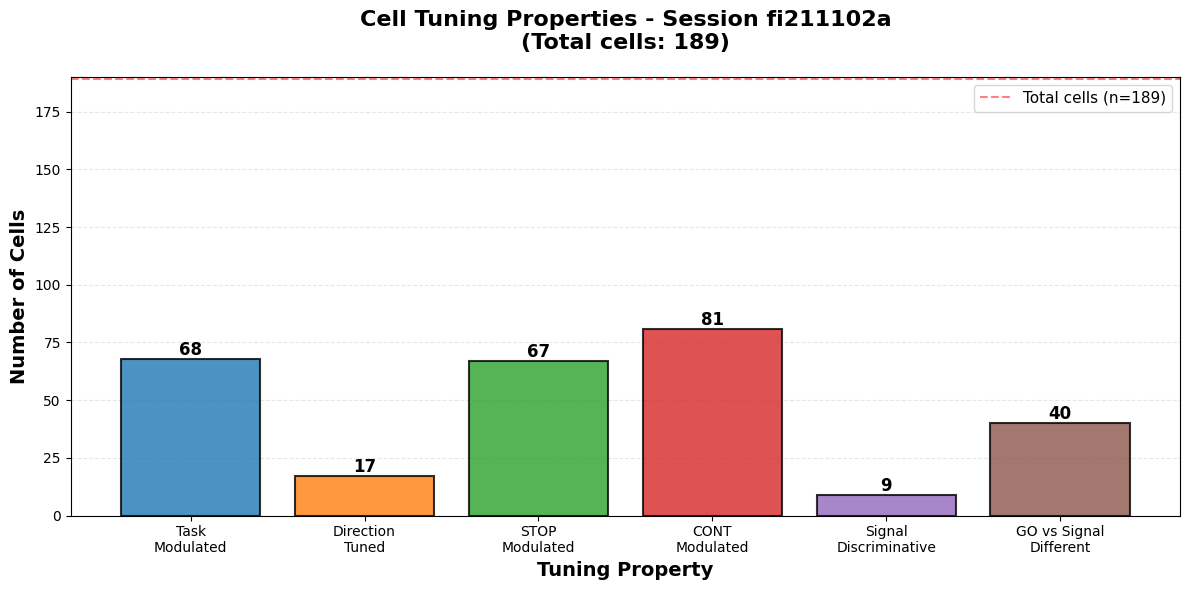


✓ Created histogram for session fi211102a with 189 cells


In [10]:
# Create histogram of tuning properties
import matplotlib.pyplot as plt

# Prepare data for histogram
tuning_properties = {
    'Task\nModulated': summary_df['is_task_modulated'].sum(),
    'Direction\nTuned': summary_df['is_direction_tuned'].sum(),
    'STOP\nModulated': summary_df['is_stop_modulated'].sum(),
    'CONT\nModulated': summary_df['is_cont_modulated'].sum(),
    'Signal\nDiscriminative': summary_df['is_signal_discriminative'].sum(),
    'GO vs Signal\nDifferent': summary_df['is_go_vs_signal_different'].sum()
}

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Create bar plot
bars = ax.bar(tuning_properties.keys(), tuning_properties.values(), 
              color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'],
              edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize plot
ax.set_ylabel('Number of Cells', fontsize=14, fontweight='bold')
ax.set_xlabel('Tuning Property', fontsize=14, fontweight='bold')
ax.set_title(f'Cell Tuning Properties - Session {best_session_id}\n(Total cells: {len(summary_df)})', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0, len(summary_df) + 1)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add horizontal line for total cells
ax.axhline(y=len(summary_df), color='red', linestyle='--', linewidth=1.5, 
           alpha=0.5, label=f'Total cells (n={len(summary_df)})')
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\n✓ Created histogram for session {best_session_id} with {len(summary_df)} cells")

## 9. Two-Way ANOVA: Task × Direction Interaction

In [11]:
from scipy.stats import f_oneway
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
def two_way_anova_task_direction(cell, alpha=0.05, verbose=False):
    """
    Two-way ANOVA to test:
    1. Main effect of task (Baseline vs GO)
    2. Main effect of direction (Left vs Right)
    3. Interaction: Task × Direction
    
    Returns:
    --------
    dict : ANOVA results with F-statistics and p-values
    """
    
    # Extract firing rates for all 4 conditions
    baseline_left = get_firing_rates(cell, 'go_cue', WINDOWS['baseline'], trial_type='GO', direction=180)
    baseline_right = get_firing_rates(cell, 'go_cue', WINDOWS['baseline'], trial_type='GO', direction=0)
    go_left = get_firing_rates(cell, 'go_cue', WINDOWS['direction'], trial_type='GO', direction=180)
    go_right = get_firing_rates(cell, 'go_cue', WINDOWS['direction'], trial_type='GO', direction=0)
    
    # Check if we have enough data
    if any(len(x) < 2 for x in [baseline_left, baseline_right, go_left, go_right]):
        return {
            'cell_id': cell.cell_id,
            'sufficient_data': False,
            'error': 'Insufficient trials in one or more conditions'
        }
    
    # Create DataFrame for ANOVA
    data_list = []
    
    # Baseline Left
    for rate in baseline_left:
        data_list.append({'firing_rate': rate, 'task': 'Baseline', 'direction': 'Left'})
    
    # Baseline Right
    for rate in baseline_right:
        data_list.append({'firing_rate': rate, 'task': 'Baseline', 'direction': 'Right'})
    
    # GO Left
    for rate in go_left:
        data_list.append({'firing_rate': rate, 'task': 'GO', 'direction': 'Left'})
    
    # GO Right
    for rate in go_right:
        data_list.append({'firing_rate': rate, 'task': 'GO', 'direction': 'Right'})
    
    df_anova = pd.DataFrame(data_list)
    
    # Fit two-way ANOVA model
    model = ols('firing_rate ~ C(task) + C(direction) + C(task):C(direction)', data=df_anova).fit()
    anova_table = anova_lm(model, typ=2)
    
    # Extract results
    results = {
        'cell_id': cell.cell_id,
        'sufficient_data': True,
        'n_baseline_left': len(baseline_left),
        'n_baseline_right': len(baseline_right),
        'n_go_left': len(go_left),
        'n_go_right': len(go_right),
        'mean_baseline_left': np.mean(baseline_left),
        'mean_baseline_right': np.mean(baseline_right),
        'mean_go_left': np.mean(go_left),
        'mean_go_right': np.mean(go_right),
        'task_effect': {
            'F': anova_table.loc['C(task)', 'F'],
            'p': anova_table.loc['C(task)', 'PR(>F)'],
            'significant': anova_table.loc['C(task)', 'PR(>F)'] < alpha
        },
        'direction_effect': {
            'F': anova_table.loc['C(direction)', 'F'],
            'p': anova_table.loc['C(direction)', 'PR(>F)'],
            'significant': anova_table.loc['C(direction)', 'PR(>F)'] < alpha
        },
        'interaction_effect': {
            'F': anova_table.loc['C(task):C(direction)', 'F'],
            'p': anova_table.loc['C(task):C(direction)', 'PR(>F)'],
            'significant': anova_table.loc['C(task):C(direction)', 'PR(>F)'] < alpha
        },
        'anova_table': anova_table
    }
    
    if verbose:
        print(f"\n{'='*70}")
        print(f"Two-Way ANOVA: Cell {cell.cell_id}")
        print(f"{'='*70}")
        print(f"\nSample sizes:")
        print(f"  Baseline Left:  n={len(baseline_left):3d}, mean={np.mean(baseline_left):6.2f} sp/s")
        print(f"  Baseline Right: n={len(baseline_right):3d}, mean={np.mean(baseline_right):6.2f} sp/s")
        print(f"  GO Left:        n={len(go_left):3d}, mean={np.mean(go_left):6.2f} sp/s")
        print(f"  GO Right:       n={len(go_right):3d}, mean={np.mean(go_right):6.2f} sp/s")
        print(f"\nANOVA Results:")
        print(anova_table)
        print(f"\nInterpretation:")
        print(f"  Main effect of Task:       {'YES' if results['task_effect']['significant'] else 'NO'} (p={results['task_effect']['p']:.4f})")
        print(f"  Main effect of Direction:  {'YES' if results['direction_effect']['significant'] else 'NO'} (p={results['direction_effect']['p']:.4f})")
        print(f"  Task × Direction interaction: {'YES' if results['interaction_effect']['significant'] else 'NO'} (p={results['interaction_effect']['p']:.4f})")
        
        if results['interaction_effect']['significant']:
            print(f"\n  ⚠ Significant interaction detected!")
            print(f"     → The GO response depends on movement direction")
    
    return results
print("✓ Two-way ANOVA function defined")


✓ Two-way ANOVA function defined


## 10. Test Two-Way ANOVA on Single Cell

In [12]:
# Test two-way ANOVA on first cell
cell_id = session.cell_ids[0]
cell = session.get_cell(cell_id)

print(f"Testing two-way ANOVA on: {cell}\n")

# Run two-way ANOVA
anova_results = two_way_anova_task_direction(cell, verbose=True)

Testing two-way ANOVA on: Cell 1834 | Type: msn | Trials: 728 | Directions: [np.int64(0), np.int64(180)] | Trial Types: ['CONT', 'GO', 'STOP'] | SSDs: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


Two-Way ANOVA: Cell 1834

Sample sizes:
  Baseline Left:  n=193, mean=  0.88 sp/s
  Baseline Right: n=201, mean=  0.41 sp/s
  GO Left:        n=193, mean=  0.37 sp/s
  GO Right:       n=201, mean=  0.70 sp/s

ANOVA Results:
                           sum_sq     df          F    PR(>F)
C(task)                  2.030457    1.0   1.055319  0.304602
C(direction)             1.098948    1.0   0.571172  0.450021
C(task):C(direction)    31.218531    1.0  16.225657  0.000062
Residual              1508.433790  784.0        NaN       NaN

Interpretation:
  Main effect of Task:       NO (p=0.3046)
  Main effect of Direction:  NO (p=0.4500)
  Task × Direction interaction: YES (p=0.0001)

  ⚠ Significant interaction detected!
     → The GO response depends on movement direction


## 11. Two-Way ANOVA Across All Cells

In [13]:
# Run two-way ANOVA on all cells
anova_results_all = []

print(f"Running two-way ANOVA on {len(session.cell_ids)} cells...\n")

for i, cell_id in enumerate(session.cell_ids):
    if (i + 1) % 10 == 0:
        print(f"  Processed {i + 1}/{len(session.cell_ids)} cells")
    
    cell = session.get_cell(cell_id)
    result = two_way_anova_task_direction(cell, verbose=False)
    anova_results_all.append(result)

print(f"\n✓ Two-way ANOVA complete for {len(anova_results_all)} cells")

# Create summary DataFrame
anova_summary_data = []

for res in anova_results_all:
    if res['sufficient_data']:
        anova_summary_data.append({
            'cell_id': res['cell_id'],
            'task_effect_significant': res['task_effect']['significant'],
            'direction_effect_significant': res['direction_effect']['significant'],
            'interaction_significant': res['interaction_effect']['significant'],
            'task_F': res['task_effect']['F'],
            'task_p': res['task_effect']['p'],
            'direction_F': res['direction_effect']['F'],
            'direction_p': res['direction_effect']['p'],
            'interaction_F': res['interaction_effect']['F'],
            'interaction_p': res['interaction_effect']['p'],
            'baseline_left_mean': res['mean_baseline_left'],
            'baseline_right_mean': res['mean_baseline_right'],
            'go_left_mean': res['mean_go_left'],
            'go_right_mean': res['mean_go_right']
        })

anova_summary_df = pd.DataFrame(anova_summary_data)

print("\n" + "="*70)
print("TWO-WAY ANOVA SUMMARY")
print("="*70)
print(f"\nTotal cells analyzed: {len(anova_summary_df)}")
print(f"\nSignificant effects (α=0.05):")
print(f"  - Main effect of Task:          {anova_summary_df['task_effect_significant'].sum():3d} ({anova_summary_df['task_effect_significant'].sum()/len(anova_summary_df)*100:5.1f}%)")
print(f"  - Main effect of Direction:     {anova_summary_df['direction_effect_significant'].sum():3d} ({anova_summary_df['direction_effect_significant'].sum()/len(anova_summary_df)*100:5.1f}%)")
print(f"  - Task × Direction Interaction: {anova_summary_df['interaction_significant'].sum():3d} ({anova_summary_df['interaction_significant'].sum()/len(anova_summary_df)*100:5.1f}%)")

# Show cells with significant interaction
if anova_summary_df['interaction_significant'].sum() > 0:
    print(f"\nCells with significant Task × Direction interaction:")
    interaction_cells = anova_summary_df[anova_summary_df['interaction_significant']]
    for _, row in interaction_cells.iterrows():
        print(f"  - Cell {row['cell_id']}: p={row['interaction_p']:.4f}")

# Display sample results
print("\n" + "="*70)
print("Sample of results:")
print("="*70)
display(anova_summary_df[['cell_id', 'task_effect_significant', 'direction_effect_significant', 
                           'interaction_significant', 'task_p', 'direction_p', 'interaction_p']].head(10))

Running two-way ANOVA on 189 cells...

  Processed 10/189 cells
  Processed 20/189 cells
  Processed 30/189 cells
  Processed 40/189 cells
  Processed 50/189 cells
  Processed 60/189 cells
  Processed 70/189 cells
  Processed 80/189 cells
  Processed 90/189 cells
  Processed 100/189 cells
  Processed 110/189 cells
  Processed 120/189 cells
  Processed 130/189 cells
  Processed 140/189 cells
  Processed 150/189 cells
  Processed 160/189 cells
  Processed 170/189 cells
  Processed 180/189 cells

✓ Two-way ANOVA complete for 189 cells

TWO-WAY ANOVA SUMMARY

Total cells analyzed: 189

Significant effects (α=0.05):
  - Main effect of Task:           79 ( 41.8%)
  - Main effect of Direction:      27 ( 14.3%)
  - Task × Direction Interaction:  28 ( 14.8%)

Cells with significant Task × Direction interaction:
  - Cell 1834: p=0.0001
  - Cell 1845: p=0.0002
  - Cell 1847: p=0.0001
  - Cell 1848: p=0.0107
  - Cell 1861: p=0.0002
  - Cell 1874: p=0.0012
  - Cell 1875: p=0.0451
  - Cell 1922: p=0

,cell_id,task_effect_significant,direction_effect_significant,interaction_significant,task_p,direction_p,interaction_p
0,1834,False,False,True,3.046022e-01,4.500205e-01,0.000062
1,1835,False,True,False,8.590732e-01,4.962212e-02,0.126072
2,1837,False,False,False,2.058965e-01,8.708013e-01,0.543261
3,1838,False,False,False,4.636274e-01,2.472216e-01,0.452933
4,1840,True,False,False,1.539732e-15,4.228696e-01,0.356665
5,1841,False,False,False,6.312674e-02,2.098596e-01,0.787747
6,1844,False,False,False,8.180300e-01,8.088085e-01,0.489470
7,1845,False,True,True,9.664173e-02,3.031699e-02,0.000203
8,1847,True,True,True,1.172723e-28,5.134237e-08,0.000061
9,1848,True,False,True,1.375318e-03,1.084467e-01,0.010699


## 12. Two-Way ANOVA: Signal × Direction Interactions

In [14]:
def two_way_anova_signal_direction(cell, signal_type='STOP', comparison='baseline', alpha=0.05, verbose=False):
    """
    Two-way ANOVA to test:
    1. Main effect of signal vs comparison period (Baseline or GO)
    2. Main effect of direction (Left vs Right)
    3. Interaction: Signal × Direction
    
    Parameters:
    -----------
    cell : Cell
        Cell object to analyze
    signal_type : str
        'STOP' or 'CONT'
    comparison : str
        'baseline' or 'GO' - what to compare signal against
    alpha : float
        Significance level
    verbose : bool
        Print detailed results
    
    Returns:
    --------
    dict : ANOVA results with F-statistics and p-values
    """
    
    # Get comparison period rates
    if comparison == 'baseline':
        comp_left = get_firing_rates(cell, 'go_cue', WINDOWS['baseline'], trial_type='GO', direction=180)
        comp_right = get_firing_rates(cell, 'go_cue', WINDOWS['baseline'], trial_type='GO', direction=0)
        comp_label = 'Baseline'
    elif comparison == 'GO':
        comp_left = get_firing_rates(cell, 'go_cue', WINDOWS['direction'], trial_type='GO', direction=180)
        comp_right = get_firing_rates(cell, 'go_cue', WINDOWS['direction'], trial_type='GO', direction=0)
        comp_label = 'GO'
    else:
        raise ValueError(f"Unknown comparison: {comparison}")
    
    # Get signal period rates (aligned to stop_cue!)
    signal_left = get_firing_rates(cell, 'stop_cue', WINDOWS['signal'], trial_type=signal_type, direction=180)
    signal_right = get_firing_rates(cell, 'stop_cue', WINDOWS['signal'], trial_type=signal_type, direction=0)
    
    # Check if we have enough data
    if any(len(x) < 2 for x in [comp_left, comp_right, signal_left, signal_right]):
        return {
            'cell_id': cell.cell_id,
            'signal_type': signal_type,
            'comparison': comparison,
            'sufficient_data': False,
            'error': 'Insufficient trials in one or more conditions'
        }
    
    # Create DataFrame for ANOVA
    data_list = []
    
    # Comparison Left
    for rate in comp_left:
        data_list.append({'firing_rate': rate, 'period': comp_label, 'direction': 'Left'})
    
    # Comparison Right
    for rate in comp_right:
        data_list.append({'firing_rate': rate, 'period': comp_label, 'direction': 'Right'})
    
    # Signal Left
    for rate in signal_left:
        data_list.append({'firing_rate': rate, 'period': signal_type, 'direction': 'Left'})
    
    # Signal Right
    for rate in signal_right:
        data_list.append({'firing_rate': rate, 'period': signal_type, 'direction': 'Right'})
    
    df_anova = pd.DataFrame(data_list)
    
    # Fit two-way ANOVA model
    model = ols('firing_rate ~ C(period) + C(direction) + C(period):C(direction)', data=df_anova).fit()
    anova_table = anova_lm(model, typ=2)
    
    # Extract results
    results = {
        'cell_id': cell.cell_id,
        'signal_type': signal_type,
        'comparison': comparison,
        'sufficient_data': True,
        'n_comp_left': len(comp_left),
        'n_comp_right': len(comp_right),
        'n_signal_left': len(signal_left),
        'n_signal_right': len(signal_right),
        'mean_comp_left': np.mean(comp_left),
        'mean_comp_right': np.mean(comp_right),
        'mean_signal_left': np.mean(signal_left),
        'mean_signal_right': np.mean(signal_right),
        'period_effect': {
            'F': anova_table.loc['C(period)', 'F'],
            'p': anova_table.loc['C(period)', 'PR(>F)'],
            'significant': anova_table.loc['C(period)', 'PR(>F)'] < alpha
        },
        'direction_effect': {
            'F': anova_table.loc['C(direction)', 'F'],
            'p': anova_table.loc['C(direction)', 'PR(>F)'],
            'significant': anova_table.loc['C(direction)', 'PR(>F)'] < alpha
        },
        'interaction_effect': {
            'F': anova_table.loc['C(period):C(direction)', 'F'],
            'p': anova_table.loc['C(period):C(direction)', 'PR(>F)'],
            'significant': anova_table.loc['C(period):C(direction)', 'PR(>F)'] < alpha
        },
        'anova_table': anova_table
    }
    
    if verbose:
        print(f"\n{'='*70}")
        print(f"Two-Way ANOVA: Cell {cell.cell_id} - {signal_type} vs {comparison}")
        print(f"{'='*70}")
        print(f"\nSample sizes:")
        print(f"  {comp_label} Left:  n={len(comp_left):3d}, mean={np.mean(comp_left):6.2f} sp/s")
        print(f"  {comp_label} Right: n={len(comp_right):3d}, mean={np.mean(comp_right):6.2f} sp/s")
        print(f"  {signal_type} Left:  n={len(signal_left):3d}, mean={np.mean(signal_left):6.2f} sp/s")
        print(f"  {signal_type} Right: n={len(signal_right):3d}, mean={np.mean(signal_right):6.2f} sp/s")
        print(f"\nANOVA Results:")
        print(anova_table)
        print(f"\nInterpretation:")
        print(f"  Main effect of Period ({comp_label} vs {signal_type}): {'YES' if results['period_effect']['significant'] else 'NO'} (p={results['period_effect']['p']:.4f})")
        print(f"  Main effect of Direction:  {'YES' if results['direction_effect']['significant'] else 'NO'} (p={results['direction_effect']['p']:.4f})")
        print(f"  Period × Direction interaction: {'YES' if results['interaction_effect']['significant'] else 'NO'} (p={results['interaction_effect']['p']:.4f})")
        
        if results['interaction_effect']['significant']:
            print(f"\n  ⚠ Significant interaction detected!")
            print(f"     → The {signal_type} response depends on movement direction differently than {comp_label}")
    
    return results
print("✓ Signal × Direction ANOVA function defined")


✓ Signal × Direction ANOVA function defined


## 13. Test Signal × Direction ANOVA on Single Cell

In [15]:
# Test signal × direction ANOVA on first cell
cell_id = session.cell_ids[0]
cell = session.get_cell(cell_id)

print(f"Testing Signal × Direction ANOVA on: {cell}\n")

# Test all 4 combinations
print("="*70)
print("STOP vs Baseline")
print("="*70)
result1 = two_way_anova_signal_direction(cell, signal_type='STOP', comparison='baseline', verbose=True)

print("\n\n" + "="*70)
print("STOP vs GO")
print("="*70)
result2 = two_way_anova_signal_direction(cell, signal_type='STOP', comparison='GO', verbose=True)

print("\n\n" + "="*70)
print("CONT vs Baseline")
print("="*70)
result3 = two_way_anova_signal_direction(cell, signal_type='CONT', comparison='baseline', verbose=True)

print("\n\n" + "="*70)
print("CONT vs GO")
print("="*70)
result4 = two_way_anova_signal_direction(cell, signal_type='CONT', comparison='GO', verbose=True)

Testing Signal × Direction ANOVA on: Cell 1834 | Type: msn | Trials: 728 | Directions: [np.int64(0), np.int64(180)] | Trial Types: ['CONT', 'GO', 'STOP'] | SSDs: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]

STOP vs Baseline

Two-Way ANOVA: Cell 1834 - STOP vs baseline

Sample sizes:
  Baseline Left:  n=193, mean=  0.88 sp/s
  Baseline Right: n=201, mean=  0.41 sp/s
  STOP Left:  n= 33, mean=  0.97 sp/s
  STOP Right: n= 41, mean=  0.88 sp/s

ANOVA Results:
                             sum_sq     df         F    PR(>F)
C(period)                  5.506852    1.0  2.490025  0.115251
C(direction)              19.928563    1.0  9.011067  0.002828
C(period):C(direction)     2.241014    1.0  1.013316  0.314634
Residual                1026.166272  464.0       NaN       NaN

Interpretation:
  Main effect of Period (Baseline vs STOP): NO (p=0.1153)
  Main effect of Direction:  YES (p=0.0028)
  Period × Direction interaction: NO (p=0.3146)


STOP vs GO

Two-Way ANOVA: Cell

## 14. Run Signal × Direction ANOVA on All Cells

In [16]:
# Run all 4 signal × direction ANOVAs on all cells
print(f"Running Signal × Direction ANOVA on {len(session.cell_ids)} cells...\n")
print("Testing 4 combinations:")
print("  1. STOP vs Baseline")
print("  2. STOP vs GO")
print("  3. CONT vs Baseline")
print("  4. CONT vs GO\n")

# Store results for each combination
stop_baseline_results = []
stop_go_results = []
cont_baseline_results = []
cont_go_results = []

for i, cell_id in enumerate(session.cell_ids):
    if (i + 1) % 20 == 0:
        print(f"  Processed {i + 1}/{len(session.cell_ids)} cells")
    
    cell = session.get_cell(cell_id)
    
    # STOP vs Baseline
    res1 = two_way_anova_signal_direction(cell, signal_type='STOP', comparison='baseline', verbose=False)
    stop_baseline_results.append(res1)
    
    # STOP vs GO
    res2 = two_way_anova_signal_direction(cell, signal_type='STOP', comparison='GO', verbose=False)
    stop_go_results.append(res2)
    
    # CONT vs Baseline
    res3 = two_way_anova_signal_direction(cell, signal_type='CONT', comparison='baseline', verbose=False)
    cont_baseline_results.append(res3)
    
    # CONT vs GO
    res4 = two_way_anova_signal_direction(cell, signal_type='CONT', comparison='GO', verbose=False)
    cont_go_results.append(res4)

print(f"\n✓ Signal × Direction ANOVA complete for all cells")

# Create summary function
def create_signal_summary(results_list, name):
    """Create summary DataFrame for a signal × direction analysis"""
    data = []
    for res in results_list:
        if res['sufficient_data']:
            data.append({
                'cell_id': res['cell_id'],
                'period_effect_significant': res['period_effect']['significant'],
                'direction_effect_significant': res['direction_effect']['significant'],
                'interaction_significant': res['interaction_effect']['significant'],
                'period_p': res['period_effect']['p'],
                'direction_p': res['direction_effect']['p'],
                'interaction_p': res['interaction_effect']['p']
            })
    
    df = pd.DataFrame(data)
    
    print(f"\n{'='*70}")
    print(f"{name}")
    print(f"{'='*70}")
    print(f"Total cells analyzed: {len(df)}")
    print(f"\nSignificant effects (α=0.05):")
    print(f"  - Main effect of Period:        {df['period_effect_significant'].sum():3d} ({df['period_effect_significant'].sum()/len(df)*100:5.1f}%)")
    print(f"  - Main effect of Direction:     {df['direction_effect_significant'].sum():3d} ({df['direction_effect_significant'].sum()/len(df)*100:5.1f}%)")
    print(f"  - Period × Direction Interaction: {df['interaction_significant'].sum():3d} ({df['interaction_significant'].sum()/len(df)*100:5.1f}%)")
    
    if df['interaction_significant'].sum() > 0:
        print(f"\nCells with significant interaction:")
        interaction_cells = df[df['interaction_significant']]
        for _, row in interaction_cells.iterrows():
            print(f"  - Cell {row['cell_id']}: p={row['interaction_p']:.4f}")
    
    return df

# Create summaries for all 4 combinations
stop_baseline_df = create_signal_summary(stop_baseline_results, "STOP vs Baseline")
stop_go_df = create_signal_summary(stop_go_results, "STOP vs GO")
cont_baseline_df = create_signal_summary(cont_baseline_results, "CONT vs Baseline")
cont_go_df = create_signal_summary(cont_go_results, "CONT vs GO")

# Overall summary
print("\n\n" + "="*70)
print("OVERALL SUMMARY: Signal × Direction Interactions")
print("="*70)
print(f"\nCells with significant interactions:")
print(f"  - STOP vs Baseline: {stop_baseline_df['interaction_significant'].sum():3d} ({stop_baseline_df['interaction_significant'].sum()/len(stop_baseline_df)*100:5.1f}%)")
print(f"  - STOP vs GO:       {stop_go_df['interaction_significant'].sum():3d} ({stop_go_df['interaction_significant'].sum()/len(stop_go_df)*100:5.1f}%)")
print(f"  - CONT vs Baseline: {cont_baseline_df['interaction_significant'].sum():3d} ({cont_baseline_df['interaction_significant'].sum()/len(cont_baseline_df)*100:5.1f}%)")
print(f"  - CONT vs GO:       {cont_go_df['interaction_significant'].sum():3d} ({cont_go_df['interaction_significant'].sum()/len(cont_go_df)*100:5.1f}%)")

Running Signal × Direction ANOVA on 189 cells...

Testing 4 combinations:
  1. STOP vs Baseline
  2. STOP vs GO
  3. CONT vs Baseline
  4. CONT vs GO

  Processed 20/189 cells
  Processed 40/189 cells
  Processed 60/189 cells
  Processed 80/189 cells
  Processed 100/189 cells
  Processed 120/189 cells
  Processed 140/189 cells
  Processed 160/189 cells
  Processed 180/189 cells

✓ Signal × Direction ANOVA complete for all cells

STOP vs Baseline
Total cells analyzed: 189

Significant effects (α=0.05):
  - Main effect of Period:         83 ( 43.9%)
  - Main effect of Direction:      14 (  7.4%)
  - Period × Direction Interaction:  31 ( 16.4%)

Cells with significant interaction:
  - Cell 1841: p=0.0238
  - Cell 1850: p=0.0462
  - Cell 1855: p=0.0015
  - Cell 1862: p=0.0101
  - Cell 1873: p=0.0352
  - Cell 1875: p=0.0399
  - Cell 1884: p=0.0494
  - Cell 1893: p=0.0098
  - Cell 1899: p=0.0090
  - Cell 1922: p=0.0015
  - Cell 1927: p=0.0013
  - Cell 3062: p=0.0005
  - Cell 3070: p=0.0025
 

Merging Signal × Direction results with Task × Direction results...
✓ Merged successfully

UPDATED ANOVA SUMMARY DATAFRAME

Showing all interaction columns:


,cell_id,interaction_significant,stop_baseline_interaction,stop_go_interaction,cont_baseline_interaction,cont_go_interaction
0,1834,True,False,False,True,False
1,1835,False,False,False,False,False
2,1837,False,False,False,False,False
3,1838,False,False,False,False,False
4,1840,False,False,False,False,False
5,1841,False,True,True,False,False
6,1844,False,False,False,False,False
7,1845,True,False,False,False,True
8,1847,True,False,False,False,False
9,1848,True,False,False,False,True



INTERACTION SUMMARY STATISTICS

Cells with significant interactions:
  Task (Baseline vs GO):      28 ( 14.8%)
  STOP vs Baseline:            1 (  0.5%)
  STOP vs GO:                  1 (  0.5%)
  CONT vs Baseline:            1 (  0.5%)
  CONT vs GO:                  1 (  0.5%)


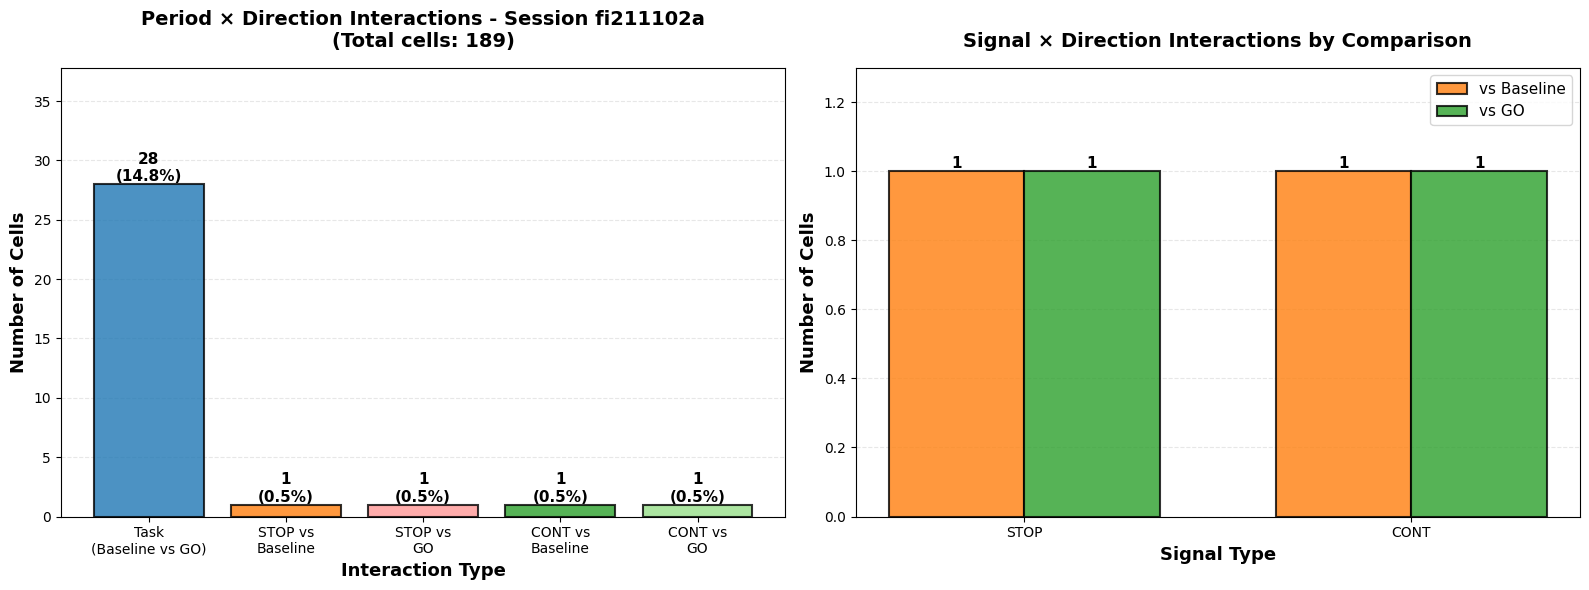


✓ Visualization complete!


In [17]:
# Merge Signal × Direction results into anova_summary_df
print("Merging Signal × Direction results with Task × Direction results...")

# Add columns for each Signal × Direction test
for cell_id in anova_summary_df['cell_id']:
    # STOP vs Baseline
    sb_row = stop_baseline_df[stop_baseline_df['cell_id'] == cell_id]
    if len(sb_row) > 0:
        anova_summary_df.loc[anova_summary_df['cell_id'] == cell_id, 'stop_baseline_interaction'] = sb_row.iloc[0]['interaction_significant']
        anova_summary_df.loc[anova_summary_df['cell_id'] == cell_id, 'stop_baseline_interaction_p'] = sb_row.iloc[0]['interaction_p']
    
    # STOP vs GO
    sg_row = stop_go_df[stop_go_df['cell_id'] == cell_id]
    if len(sg_row) > 0:
        anova_summary_df.loc[anova_summary_df['cell_id'] == cell_id, 'stop_go_interaction'] = sg_row.iloc[0]['interaction_significant']
        anova_summary_df.loc[anova_summary_df['cell_id'] == cell_id, 'stop_go_interaction_p'] = sg_row.iloc[0]['interaction_p']
    
    # CONT vs Baseline
    cb_row = cont_baseline_df[cont_baseline_df['cell_id'] == cell_id]
    if len(cb_row) > 0:
        anova_summary_df.loc[anova_summary_df['cell_id'] == cell_id, 'cont_baseline_interaction'] = cb_row.iloc[0]['interaction_significant']
        anova_summary_df.loc[anova_summary_df['cell_id'] == cell_id, 'cont_baseline_interaction_p'] = cb_row.iloc[0]['interaction_p']
    
    # CONT vs GO
    cg_row = cont_go_df[cont_go_df['cell_id'] == cell_id]
    if len(cg_row) > 0:
        anova_summary_df.loc[anova_summary_df['cell_id'] == cell_id, 'cont_go_interaction'] = cg_row.iloc[0]['interaction_significant']
        anova_summary_df.loc[anova_summary_df['cell_id'] == cell_id, 'cont_go_interaction_p'] = cg_row.iloc[0]['interaction_p']

print("✓ Merged successfully\n")

# Display the updated dataframe
print("="*70)
print("UPDATED ANOVA SUMMARY DATAFRAME")
print("="*70)
print(f"\nShowing all interaction columns:")
interaction_cols = ['cell_id', 'interaction_significant', 'stop_baseline_interaction', 
                    'stop_go_interaction', 'cont_baseline_interaction', 'cont_go_interaction']
display(anova_summary_df[interaction_cols].head(20))

# Summary statistics
print("\n" + "="*70)
print("INTERACTION SUMMARY STATISTICS")
print("="*70)
print(f"\nCells with significant interactions:")
print(f"  Task (Baseline vs GO):     {anova_summary_df['interaction_significant'].sum():3d} ({anova_summary_df['interaction_significant'].sum()/len(anova_summary_df)*100:5.1f}%)")
print(f"  STOP vs Baseline:          {anova_summary_df['stop_baseline_interaction'].sum():3d} ({anova_summary_df['stop_baseline_interaction'].sum()/len(anova_summary_df)*100:5.1f}%)")
print(f"  STOP vs GO:                {anova_summary_df['stop_go_interaction'].sum():3d} ({anova_summary_df['stop_go_interaction'].sum()/len(anova_summary_df)*100:5.1f}%)")
print(f"  CONT vs Baseline:          {anova_summary_df['cont_baseline_interaction'].sum():3d} ({anova_summary_df['cont_baseline_interaction'].sum()/len(anova_summary_df)*100:5.1f}%)")
print(f"  CONT vs GO:                {anova_summary_df['cont_go_interaction'].sum():3d} ({anova_summary_df['cont_go_interaction'].sum()/len(anova_summary_df)*100:5.1f}%)")

# Create visualization
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart of interaction percentages
interaction_data = {
    'Task\n(Baseline vs GO)': anova_summary_df['interaction_significant'].sum(),
    'STOP vs\nBaseline': anova_summary_df['stop_baseline_interaction'].sum(),
    'STOP vs\nGO': anova_summary_df['stop_go_interaction'].sum(),
    'CONT vs\nBaseline': anova_summary_df['cont_baseline_interaction'].sum(),
    'CONT vs\nGO': anova_summary_df['cont_go_interaction'].sum()
}

colors = ['#1f77b4', '#ff7f0e', '#ff9896', '#2ca02c', '#98df8a']
bars = ax1.bar(interaction_data.keys(), interaction_data.values(), 
               color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({int(height)/len(anova_summary_df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_ylabel('Number of Cells', fontsize=13, fontweight='bold')
ax1.set_xlabel('Interaction Type', fontsize=13, fontweight='bold')
ax1.set_title(f'Period × Direction Interactions - Session {best_session_id}\n(Total cells: {len(anova_summary_df)})', 
             fontsize=14, fontweight='bold', pad=15)
ax1.set_ylim(0, len(anova_summary_df) * 0.2)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Plot 2: Grouped comparison
signal_types = ['STOP', 'CONT']
vs_baseline = [anova_summary_df['stop_baseline_interaction'].sum(), 
               anova_summary_df['cont_baseline_interaction'].sum()]
vs_go = [anova_summary_df['stop_go_interaction'].sum(), 
         anova_summary_df['cont_go_interaction'].sum()]

x = np.arange(len(signal_types))
width = 0.35

bars1 = ax2.bar(x - width/2, vs_baseline, width, label='vs Baseline', 
                color='#ff7f0e', edgecolor='black', linewidth=1.5, alpha=0.8)
bars2 = ax2.bar(x + width/2, vs_go, width, label='vs GO', 
                color='#2ca02c', edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylabel('Number of Cells', fontsize=13, fontweight='bold')
ax2.set_xlabel('Signal Type', fontsize=13, fontweight='bold')
ax2.set_title('Signal × Direction Interactions by Comparison', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(signal_types)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
ax2.set_ylim(0, max(max(vs_baseline), max(vs_go)) * 1.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")

In [18]:
# Merge all results into a single unified DataFrame
print("="*80)
print("CREATING UNIFIED RESULTS DATAFRAME")
print("="*80)

# Merge summary_df and anova_summary_df on cell_id
unified_df = pd.merge(summary_df, anova_summary_df, on='cell_id', how='outer')

# Reorder columns for better readability
column_order = [
    # Cell identification
    'cell_id',
    
    # Basic tuning properties (from summary_df)
    'is_task_modulated',
    'is_direction_tuned',
    'is_stop_modulated',
    'is_cont_modulated',
    'is_signal_discriminative',
    'is_go_vs_signal_different',
    
    # Firing rates
    'baseline_FR',
    'go_FR',
    'stop_FR',
    'cont_FR',
    
    # Selectivity indices
    'DSI',
    'SSI',
    
    # Preferred directions/signals
    'preferred_direction',
    'preferred_signal',
    
    # P-values from one-way ANOVAs
    'task_mod_p',
    'dir_tuning_p',
    'stop_mod_p',
    'cont_mod_p',
    'signal_disc_p',
    'go_vs_signal_p',
    
    # Two-way ANOVA: Task × Direction (from anova_summary_df)
    'task_effect_significant',
    'direction_effect_significant',
    'interaction_significant',
    'task_F',
    'task_p',
    'direction_F',
    'direction_p',
    'interaction_F',
    'interaction_p',
    
    # Two-way ANOVA: Signal × Direction interactions
    'stop_baseline_interaction',
    'stop_baseline_interaction_p',
    'stop_go_interaction',
    'stop_go_interaction_p',
    'cont_baseline_interaction',
    'cont_baseline_interaction_p',
    'cont_go_interaction',
    'cont_go_interaction_p',
    
    # Mean firing rates for two-way ANOVA conditions
    'baseline_left_mean',
    'baseline_right_mean',
    'go_left_mean',
    'go_right_mean',
    
    # Tuning profile
    'tuning_profile'
]

# Select only columns that exist
existing_columns = [col for col in column_order if col in unified_df.columns]
unified_df = unified_df[existing_columns]

print(f"\n✓ Unified DataFrame created with {len(unified_df)} cells and {len(unified_df.columns)} columns")
print(f"\nDataFrame shape: {unified_df.shape}")
print(f"\nFirst 10 rows:")
print("="*80)
display(unified_df.head(10))

# Save to CSV for easy access
output_path = Path.cwd().parent / 'data' / f'cell_tuning_results_{best_session_id}.csv'
unified_df.to_csv(output_path, index=False)
print(f"\n✓ Saved unified results to: {output_path}")

CREATING UNIFIED RESULTS DATAFRAME

✓ Unified DataFrame created with 189 cells and 43 columns

DataFrame shape: (189, 43)

First 10 rows:


,cell_id,is_task_modulated,is_direction_tuned,is_stop_modulated,is_cont_modulated,is_signal_discriminative,is_go_vs_signal_different,baseline_FR,go_FR,stop_FR,...,stop_go_interaction_p,cont_baseline_interaction,cont_baseline_interaction_p,cont_go_interaction,cont_go_interaction_p,baseline_left_mean,baseline_right_mean,go_left_mean,go_right_mean,tuning_profile
0,1834,False,False,False,False,False,False,0.639594,0.499154,0.918919,...,0.302473,True,0.000104,False,0.444177,0.880829,0.407960,0.373057,0.696517,not_tuned
1,1835,False,False,False,False,False,False,0.892308,0.861538,0.745763,...,0.948597,False,0.715504,False,0.452909,0.930818,0.855422,1.232704,0.626506,not_tuned
2,1837,False,False,False,False,False,False,1.389163,1.059113,1.226667,...,0.720254,False,0.124456,False,0.332435,1.346734,1.429952,1.226131,1.082126,not_tuned
3,1838,False,False,False,False,False,False,0.083333,0.059524,0.142857,...,0.336723,False,0.863957,False,0.397159,0.093023,0.073171,0.093023,0.000000,not_tuned
4,1840,True,False,True,True,True,False,6.743842,5.550082,4.746667,...,0.967101,False,0.481260,False,0.250278,6.753769,6.734300,5.286432,5.565217,"task_modulated, stop_modulated, cont_modulated..."
5,1841,False,False,False,False,False,False,0.137931,0.065681,0.213333,...,0.001935,False,0.284462,False,0.106191,0.170854,0.106280,0.080402,0.038647,not_tuned
6,1844,False,False,False,False,False,False,0.046948,0.046948,0.205128,...,0.161542,False,0.445293,False,0.267283,0.056075,0.037736,0.037383,0.075472,not_tuned
7,1845,False,True,False,True,False,True,5.215686,5.016340,4.842105,...,0.198867,False,0.785556,True,0.027978,5.454545,4.990476,4.808081,6.552381,"direction_tuned_right, cont_modulated, go_vs_s..."
8,1847,True,True,True,True,False,True,4.584980,10.711462,17.360000,...,0.065197,False,0.459780,False,0.071783,4.169231,5.024390,8.707692,14.211382,"task_modulated, direction_tuned_right, stop_mo..."
9,1848,False,False,True,False,False,False,10.626984,11.891534,13.920000,...,0.565042,False,0.555497,True,0.029254,10.899225,10.341463,11.317829,13.756098,stop_modulated



✓ Saved unified results to: /home/barak/Projects/population-analysis/data/cell_tuning_results_fi211102a.csv


In [19]:
# Print comprehensive column explanations
print("\n" + "="*80)
print("UNIFIED DATAFRAME COLUMN EXPLANATIONS")
print("="*80)

column_explanations = {
    # Cell identification
    'cell_id': {
        'description': 'Unique identifier for each neuron',
        'type': 'int',
        'source': 'Cell database'
    },
    
    # Basic tuning properties (Boolean flags from one-way ANOVAs)
    'is_task_modulated': {
        'description': 'Whether cell shows significant modulation during GO trials vs baseline',
        'type': 'bool',
        'test': 'One-way ANOVA (Bonferroni corrected, α=0.05/6)',
        'interpretation': 'True = cell changes firing rate during task execution'
    },
    'is_direction_tuned': {
        'description': 'Whether cell discriminates between left (180°) and right (0°) movement directions',
        'type': 'bool',
        'test': 'One-way ANOVA on GO trials (Bonferroni corrected)',
        'interpretation': 'True = cell prefers one movement direction over the other'
    },
    'is_stop_modulated': {
        'description': 'Whether cell responds to STOP signal (aligned to stop_cue)',
        'type': 'bool',
        'test': 'One-way ANOVA: Baseline vs STOP response (Bonferroni corrected)',
        'interpretation': 'True = cell changes firing rate in response to STOP signal'
    },
    'is_cont_modulated': {
        'description': 'Whether cell responds to CONT (continue) signal (aligned to stop_cue)',
        'type': 'bool',
        'test': 'One-way ANOVA: Baseline vs CONT response (Bonferroni corrected)',
        'interpretation': 'True = cell changes firing rate in response to CONT signal'
    },
    'is_signal_discriminative': {
        'description': 'Whether cell distinguishes between STOP and CONT signals',
        'type': 'bool',
        'test': 'One-way ANOVA: STOP vs CONT (both aligned to stop_cue, Bonferroni corrected)',
        'interpretation': 'True = cell differentially responds to STOP vs CONT signals'
    },
    'is_go_vs_signal_different': {
        'description': 'Whether signal responses (STOP/CONT) differ from GO response',
        'type': 'bool',
        'test': 'One-way ANOVA: GO vs STOP vs CONT (Bonferroni corrected)',
        'interpretation': 'True = signals modulate activity differently than GO'
    },
    
    # Firing rates (spikes/second)
    'baseline_FR': {
        'description': 'Mean firing rate during baseline period [-500, 0ms] before go_cue',
        'type': 'float',
        'units': 'spikes/sec',
        'window': '[-500, 0ms] aligned to go_cue on GO trials'
    },
    'go_FR': {
        'description': 'Mean firing rate during GO task execution',
        'type': 'float',
        'units': 'spikes/sec',
        'window': '[0, 500ms] aligned to go_cue on GO trials'
    },
    'stop_FR': {
        'description': 'Mean firing rate during STOP signal response',
        'type': 'float',
        'units': 'spikes/sec',
        'window': '[0, 500ms] aligned to stop_cue on STOP trials'
    },
    'cont_FR': {
        'description': 'Mean firing rate during CONT signal response',
        'type': 'float',
        'units': 'spikes/sec',
        'window': '[0, 500ms] aligned to stop_cue on CONT trials'
    },
    
    # Selectivity indices
    'DSI': {
        'description': 'Direction Selectivity Index: (Left - Right) / (Left + Right)',
        'type': 'float',
        'range': '[-1, 1]',
        'interpretation': 'Positive = left preference, Negative = right preference, 0 = no preference'
    },
    'SSI': {
        'description': 'Signal Selectivity Index: (STOP - CONT) / (STOP + CONT)',
        'type': 'float',
        'range': '[-1, 1]',
        'interpretation': 'Positive = STOP preference, Negative = CONT preference, 0 = no preference'
    },
    
    # Preferred directions/signals
    'preferred_direction': {
        'description': 'Preferred movement direction based on higher firing rate',
        'type': 'str',
        'values': 'left, right, or none',
        'note': 'Only meaningful if is_direction_tuned = True'
    },
    'preferred_signal': {
        'description': 'Preferred signal type based on higher firing rate',
        'type': 'str',
        'values': 'STOP, CONT, or none',
        'note': 'Only meaningful if is_signal_discriminative = True'
    },
    
    # P-values from one-way ANOVAs
    'task_mod_p': {
        'description': 'P-value for task modulation test (Baseline vs GO)',
        'type': 'float',
        'range': '[0, 1]',
        'note': 'Uncorrected p-value; compare to Bonferroni-corrected α = 0.05/6'
    },
    'dir_tuning_p': {
        'description': 'P-value for direction tuning test (Left vs Right on GO trials)',
        'type': 'float',
        'range': '[0, 1]',
        'note': 'Uncorrected p-value; compare to Bonferroni-corrected α'
    },
    'stop_mod_p': {
        'description': 'P-value for STOP modulation test (Baseline vs STOP)',
        'type': 'float',
        'range': '[0, 1]',
        'note': 'STOP trials aligned to stop_cue; uncorrected p-value'
    },
    'cont_mod_p': {
        'description': 'P-value for CONT modulation test (Baseline vs CONT)',
        'type': 'float',
        'range': '[0, 1]',
        'note': 'CONT trials aligned to stop_cue; uncorrected p-value'
    },
    'signal_disc_p': {
        'description': 'P-value for signal discrimination test (STOP vs CONT)',
        'type': 'float',
        'range': '[0, 1]',
        'note': 'Both signals aligned to stop_cue; uncorrected p-value'
    },
    'go_vs_signal_p': {
        'description': 'P-value for GO vs Signals test (GO vs STOP vs CONT)',
        'type': 'float',
        'range': '[0, 1]',
        'note': 'Tests if signal responses differ from GO response; uncorrected p-value'
    },
    
    # Two-way ANOVA: Task × Direction
    'task_effect_significant': {
        'description': 'Main effect of task in Task × Direction two-way ANOVA',
        'type': 'bool',
        'test': 'Two-way ANOVA: Task (Baseline vs GO) × Direction (Left vs Right)',
        'interpretation': 'True = significant main effect of task period (α=0.05)'
    },
    'direction_effect_significant': {
        'description': 'Main effect of direction in Task × Direction two-way ANOVA',
        'type': 'bool',
        'test': 'Two-way ANOVA: Task × Direction',
        'interpretation': 'True = significant main effect of movement direction (α=0.05)'
    },
    'interaction_significant': {
        'description': 'Task × Direction interaction effect',
        'type': 'bool',
        'test': 'Two-way ANOVA interaction term',
        'interpretation': 'True = GO response depends on movement direction (α=0.05)'
    },
    'task_F': {
        'description': 'F-statistic for main effect of task',
        'type': 'float',
        'test': 'Two-way ANOVA'
    },
    'task_p': {
        'description': 'P-value for main effect of task',
        'type': 'float',
        'range': '[0, 1]',
        'test': 'Two-way ANOVA'
    },
    'direction_F': {
        'description': 'F-statistic for main effect of direction',
        'type': 'float',
        'test': 'Two-way ANOVA'
    },
    'direction_p': {
        'description': 'P-value for main effect of direction',
        'type': 'float',
        'range': '[0, 1]',
        'test': 'Two-way ANOVA'
    },
    'interaction_F': {
        'description': 'F-statistic for Task × Direction interaction',
        'type': 'float',
        'test': 'Two-way ANOVA'
    },
    'interaction_p': {
        'description': 'P-value for Task × Direction interaction',
        'type': 'float',
        'range': '[0, 1]',
        'test': 'Two-way ANOVA'
    },
    
    # Two-way ANOVA: Signal × Direction interactions
    'stop_baseline_interaction': {
        'description': 'STOP × Direction interaction: Does STOP response depend on direction differently than baseline?',
        'type': 'bool',
        'test': 'Two-way ANOVA: Period (Baseline vs STOP) × Direction',
        'interpretation': 'True = STOP response is direction-dependent (α=0.05)'
    },
    'stop_baseline_interaction_p': {
        'description': 'P-value for STOP × Direction interaction (vs Baseline)',
        'type': 'float',
        'range': '[0, 1]'
    },
    'stop_go_interaction': {
        'description': 'STOP × Direction interaction: Does STOP response depend on direction differently than GO?',
        'type': 'bool',
        'test': 'Two-way ANOVA: Period (GO vs STOP) × Direction',
        'interpretation': 'True = STOP has direction-specific effect different from GO (α=0.05)'
    },
    'stop_go_interaction_p': {
        'description': 'P-value for STOP × Direction interaction (vs GO)',
        'type': 'float',
        'range': '[0, 1]'
    },
    'cont_baseline_interaction': {
        'description': 'CONT × Direction interaction: Does CONT response depend on direction differently than baseline?',
        'type': 'bool',
        'test': 'Two-way ANOVA: Period (Baseline vs CONT) × Direction',
        'interpretation': 'True = CONT response is direction-dependent (α=0.05)'
    },
    'cont_baseline_interaction_p': {
        'description': 'P-value for CONT × Direction interaction (vs Baseline)',
        'type': 'float',
        'range': '[0, 1]'
    },
    'cont_go_interaction': {
        'description': 'CONT × Direction interaction: Does CONT response depend on direction differently than GO?',
        'type': 'bool',
        'test': 'Two-way ANOVA: Period (GO vs CONT) × Direction',
        'interpretation': 'True = CONT has direction-specific effect different from GO (α=0.05)'
    },
    'cont_go_interaction_p': {
        'description': 'P-value for CONT × Direction interaction (vs GO)',
        'type': 'float',
        'range': '[0, 1]'
    },
    
    # Mean firing rates for two-way ANOVA conditions
    'baseline_left_mean': {
        'description': 'Mean firing rate during baseline period for leftward trials',
        'type': 'float',
        'units': 'spikes/sec',
        'window': '[-500, 0ms] aligned to go_cue, direction=180°'
    },
    'baseline_right_mean': {
        'description': 'Mean firing rate during baseline period for rightward trials',
        'type': 'float',
        'units': 'spikes/sec',
        'window': '[-500, 0ms] aligned to go_cue, direction=0°'
    },
    'go_left_mean': {
        'description': 'Mean firing rate during GO period for leftward trials',
        'type': 'float',
        'units': 'spikes/sec',
        'window': '[0, 500ms] aligned to go_cue, direction=180°'
    },
    'go_right_mean': {
        'description': 'Mean firing rate during GO period for rightward trials',
        'type': 'float',
        'units': 'spikes/sec',
        'window': '[0, 500ms] aligned to go_cue, direction=0°'
    },
    
    # Tuning profile
    'tuning_profile': {
        'description': 'Comma-separated summary of all significant tuning properties',
        'type': 'str',
        'examples': 'task_modulated, direction_tuned_left, stop_modulated, signal_selective_STOP',
        'interpretation': 'Comprehensive summary of cell functional properties'
    }
}

# Print organized explanations
print("\n" + "-"*80)
print("CELL IDENTIFICATION")
print("-"*80)
for col in ['cell_id']:
    if col in column_explanations:
        print(f"\n{col}:")
        for key, val in column_explanations[col].items():
            print(f"  {key}: {val}")

print("\n" + "-"*80)
print("BASIC TUNING PROPERTIES (One-Way ANOVAs with Bonferroni Correction)")
print("-"*80)
tuning_cols = ['is_task_modulated', 'is_direction_tuned', 'is_stop_modulated', 
               'is_cont_modulated', 'is_signal_discriminative', 'is_go_vs_signal_different']
for col in tuning_cols:
    if col in column_explanations:
        print(f"\n{col}:")
        for key, val in column_explanations[col].items():
            print(f"  {key}: {val}")

print("\n" + "-"*80)
print("FIRING RATES (spikes/sec)")
print("-"*80)
fr_cols = ['baseline_FR', 'go_FR', 'stop_FR', 'cont_FR']
for col in fr_cols:
    if col in column_explanations:
        print(f"\n{col}:")
        for key, val in column_explanations[col].items():
            print(f"  {key}: {val}")

print("\n" + "-"*80)
print("SELECTIVITY INDICES")
print("-"*80)
index_cols = ['DSI', 'SSI', 'preferred_direction', 'preferred_signal']
for col in index_cols:
    if col in column_explanations:
        print(f"\n{col}:")
        for key, val in column_explanations[col].items():
            print(f"  {key}: {val}")

print("\n" + "-"*80)
print("P-VALUES FROM ONE-WAY ANOVAs (Uncorrected)")
print("-"*80)
pval_cols = ['task_mod_p', 'dir_tuning_p', 'stop_mod_p', 'cont_mod_p', 'signal_disc_p', 'go_vs_signal_p']
for col in pval_cols:
    if col in column_explanations:
        print(f"\n{col}:")
        for key, val in column_explanations[col].items():
            print(f"  {key}: {val}")

print("\n" + "-"*80)
print("TWO-WAY ANOVA: TASK × DIRECTION")
print("-"*80)
anova_cols = ['task_effect_significant', 'direction_effect_significant', 'interaction_significant',
              'task_F', 'task_p', 'direction_F', 'direction_p', 'interaction_F', 'interaction_p']
for col in anova_cols:
    if col in column_explanations:
        print(f"\n{col}:")
        for key, val in column_explanations[col].items():
            print(f"  {key}: {val}")

print("\n" + "-"*80)
print("TWO-WAY ANOVA: SIGNAL × DIRECTION INTERACTIONS")
print("-"*80)
signal_int_cols = ['stop_baseline_interaction', 'stop_baseline_interaction_p',
                   'stop_go_interaction', 'stop_go_interaction_p',
                   'cont_baseline_interaction', 'cont_baseline_interaction_p',
                   'cont_go_interaction', 'cont_go_interaction_p']
for col in signal_int_cols:
    if col in column_explanations:
        print(f"\n{col}:")
        for key, val in column_explanations[col].items():
            print(f"  {key}: {val}")

print("\n" + "-"*80)
print("MEAN FIRING RATES FOR TWO-WAY ANOVA CONDITIONS")
print("-"*80)
mean_cols = ['baseline_left_mean', 'baseline_right_mean', 'go_left_mean', 'go_right_mean']
for col in mean_cols:
    if col in column_explanations:
        print(f"\n{col}:")
        for key, val in column_explanations[col].items():
            print(f"  {key}: {val}")

print("\n" + "-"*80)
print("SUMMARY")
print("-"*80)
for col in ['tuning_profile']:
    if col in column_explanations:
        print(f"\n{col}:")
        for key, val in column_explanations[col].items():
            print(f"  {key}: {val}")

print("\n" + "="*80)
print("KEY NOTES:")
print("="*80)
print("""
1. ALIGNMENT: 
   - GO trials: All measurements aligned to go_cue
   - STOP/CONT trials: Signal responses aligned to stop_cue (CORRECTED in this analysis)
   
2. BONFERRONI CORRECTION:
   - One-way ANOVAs use Bonferroni correction (α = 0.05/6 = 0.0083) 
   - Two-way ANOVAs use uncorrected α = 0.05

3. TIME WINDOWS:
   - Baseline: [-500, 0ms] before go_cue
   - Task periods (GO/STOP/CONT): [0, 500ms] after respective cue

4. DIRECTIONS:
   - Left = 180°
   - Right = 0°

5. TRIAL TYPES:
   - GO: Execute saccade to target
   - STOP: Inhibit saccade (red signal)
   - CONT: Continue saccade (green signal)
""")


UNIFIED DATAFRAME COLUMN EXPLANATIONS

--------------------------------------------------------------------------------
CELL IDENTIFICATION
--------------------------------------------------------------------------------

cell_id:
  description: Unique identifier for each neuron
  type: int
  source: Cell database

--------------------------------------------------------------------------------
BASIC TUNING PROPERTIES (One-Way ANOVAs with Bonferroni Correction)
--------------------------------------------------------------------------------

is_task_modulated:
  description: Whether cell shows significant modulation during GO trials vs baseline
  type: bool
  test: One-way ANOVA (Bonferroni corrected, α=0.05/6)
  interpretation: True = cell changes firing rate during task execution

is_direction_tuned:
  description: Whether cell discriminates between left (180°) and right (0°) movement directions
  type: bool
  test: One-way ANOVA on GO trials (Bonferroni corrected)
  interpretation:

## Enhanced Visualizations
New plots to inspect effect sizes, GO vs signal responses, and tuning-space embeddings.

### Effect Size Distributions
Violin/box plots for Cohen's d, eta-squared, DSI, and SSI split by significance.

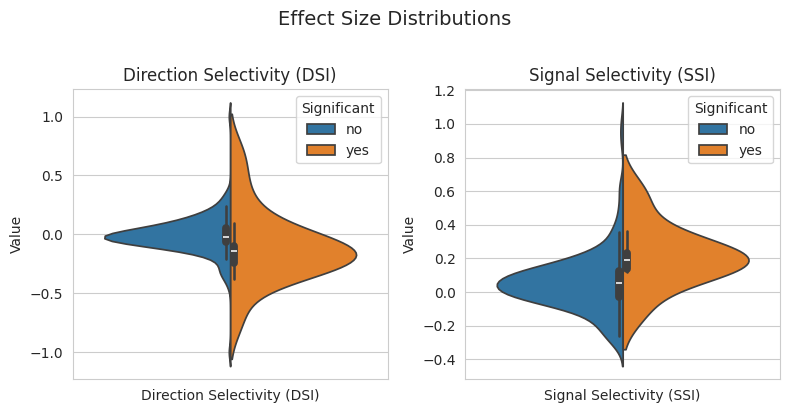

In [20]:

import matplotlib.pyplot as plt
try:
    import seaborn as sns
    sns.set_style('whitegrid')
except ImportError:
    sns = None

effect_cols = {
    'Task Cohen d': ('cohens_d_task', 'is_task_modulated'),
    'Direction Cohen d': ('cohens_d_direction', 'is_direction_tuned'),
    'Direction Selectivity (DSI)': ('DSI', 'is_direction_tuned'),
    'Signal Selectivity (SSI)': ('SSI', 'is_signal_discriminative'),
}
long_rows = []
for label, (col, flag) in effect_cols.items():
    if col not in summary_df:
        continue
    for val, sig in zip(summary_df[col], summary_df[flag]):
        if pd.isna(val):
            continue
        long_rows.append({'metric': label, 'value': val, 'significant': 'yes' if sig else 'no'})
effect_long = pd.DataFrame(long_rows)
if effect_long.empty:
    print('No effect-size data available for plotting.')
else:
    fig, axes = plt.subplots(1, len(effect_long['metric'].unique()), figsize=(4*len(effect_long['metric'].unique()), 4), sharey=False)
    if len(effect_long['metric'].unique()) == 1:
        axes = [axes]
    for ax, metric in zip(axes, effect_long['metric'].unique()):
        subset = effect_long[effect_long['metric'] == metric]
        if sns:
            sns.violinplot(data=subset, x='metric', y='value', hue='significant', split=True, ax=ax, inner='box')
        else:
            subset.boxplot(by='significant', column='value', ax=ax)
        ax.set_title(metric)
        ax.set_xlabel('')
        ax.set_ylabel('Value')
        ax.legend(title='Significant', loc='best')
    fig.suptitle('Effect Size Distributions', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


### GO vs Signal Scatter
Compare GO firing rates to STOP/CONT responses with significance coloring.

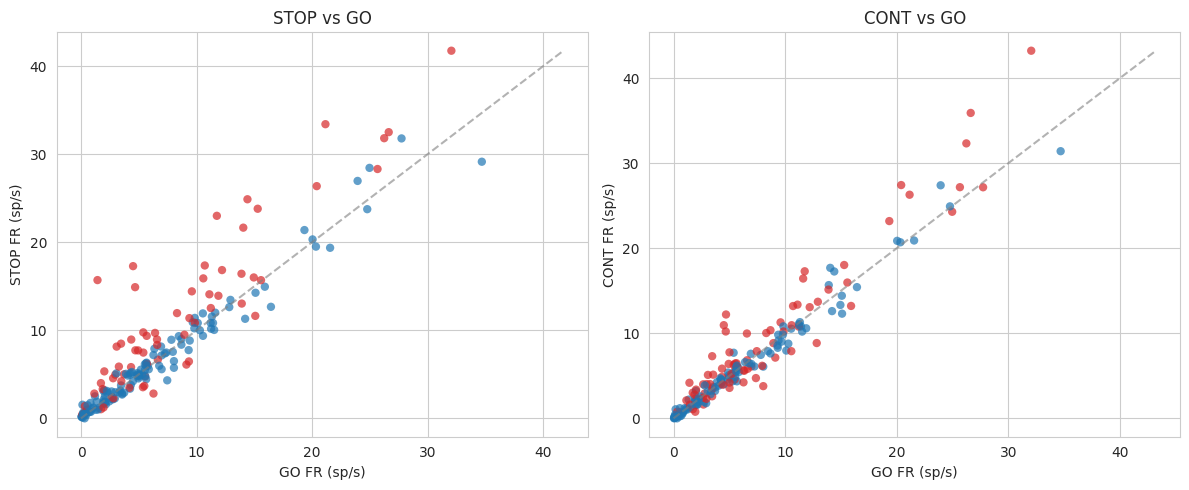

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
scatter_sets = [
    ('STOP vs GO', 'stop_FR', 'is_stop_modulated'),
    ('CONT vs GO', 'cont_FR', 'is_cont_modulated'),
]
for ax, (title, col, flag) in zip(axes, scatter_sets):
    if col not in summary_df:
        ax.text(0.5, 0.5, f'Missing column {col}', ha='center')
        continue
    x = summary_df['go_FR']
    y = summary_df[col]
    colors = summary_df[flag].map({True: '#d62728', False: '#1f77b4'}) if flag in summary_df else '#1f77b4'
    ax.scatter(x, y, c=colors, alpha=0.7, edgecolor='none')
    max_val = pd.concat([x, y]).max()
    ax.plot([0, max_val], [0, max_val], ls='--', color='gray', alpha=0.6)
    ax.set_xlabel('GO FR (sp/s)')
    ax.set_ylabel(f"{title.split()[0]} FR (sp/s)")
    ax.set_title(title)
plt.tight_layout()
plt.show()


### Tuning-Space Embedding
PCA over tuning metrics to see clustering by profile.

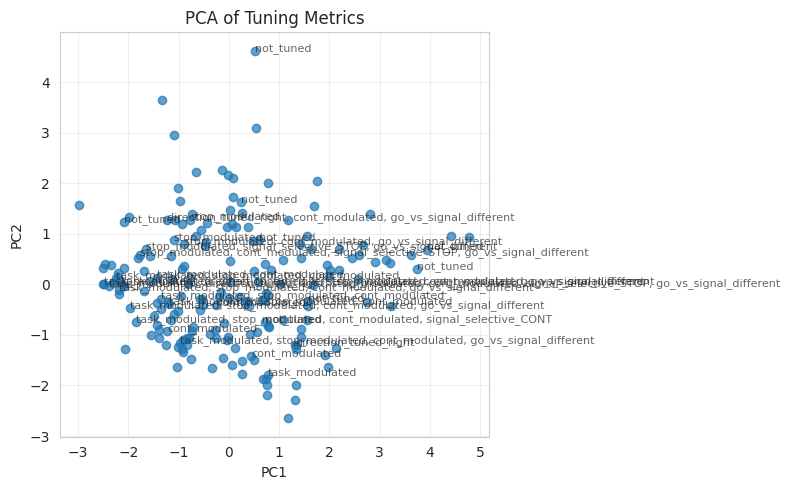

In [22]:

try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
except ImportError:
    print('sklearn not available; install scikit-learn to run PCA embedding.')
else:
    feature_cols = [
        'task_mod_p', 'dir_tuning_p', 'stop_mod_p', 'cont_mod_p', 'signal_disc_p', 'go_vs_signal_p',
        'cohens_d_task', 'cohens_d_direction', 'DSI', 'SSI'
    ]
    features = [c for c in feature_cols if c in summary_df]
    emb_df = summary_df[features].dropna()
    if len(emb_df) < 5:
        print('Not enough complete rows for PCA embedding.')
    else:
        X = StandardScaler().fit_transform(emb_df.values)
        pcs = PCA(n_components=2).fit_transform(X)
        labels = summary_df.loc[emb_df.index, 'tuning_profile'] if 'tuning_profile' in summary_df else None
        plt.figure(figsize=(7, 5))
        plt.scatter(pcs[:,0], pcs[:,1], c='#1f77b4', alpha=0.7)
        if labels is not None:
            for i, txt in enumerate(labels):
                if i < 30:  # avoid clutter
                    plt.text(pcs[i,0], pcs[i,1], txt, fontsize=8, alpha=0.7)
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.title('PCA of Tuning Metrics')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
